# 2. Task 1: Text preprocessing & vectorization

We build 4 vectorizations of our trail descriptions:
1. TF-IDF (classical)
2. FastText averaged embeddings (embedding-based)
3. LDA topic vectors (topic modeling)
4. BERT sentence embeddings (contextual)

In [1]:
# pip install spacy gensim sentence-transformers scikit-learn
# python -m spacy download en_core_web_sm

import pickle
from pathlib import Path
import pandas as pd
import numpy as np

df = pd.read_pickle("../data/trails.pkl")
print(f"{len(df)} trails loaded")

# we'll work with the description as the main text document
texts_raw = df["description"].tolist()
ids = df["tour_id"].tolist()

5642 trails loaded


## Step 1 — Text preprocessing pipeline

Using SpaCy: tokenize, lowercase, remove stopwords and punctuation, lemmatize.

In [ ]:
import spacy

# load English model: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess(text: str) -> list[str]:
    """Return list of clean lemmas from a text"""
    doc = nlp(text.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop       # stopwords
        and not token.is_punct     # punctuation
        and not token.is_space     # whitespace
        and len(token.lemma_) > 2  # skip short tokens
    ]
    return tokens

# process all descriptions
print("Preprocessing texts...")
tokenized = [preprocess(t) for t in texts_raw]

# quick sanity check
print("Example:", tokenized[0][:10])

Preprocessing texts...
Example: ['explore', 'toro', 'spain', 'easy', '2.7', 'mile', 'circular', 'hike', 'feature', 'historic']


In [4]:
# join tokens back to strings for TF-IDF and BERT
texts_clean = [" ".join(tokens) for tokens in tokenized]

# save tokenized texts for LDA and FastText
with open("../data/tokenized.pkl", "wb") as f:
    pickle.dump(tokenized, f)

print("Saved tokenized texts")

Saved tokenized texts


## Step 2a — TF-IDF (classical approach)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features limits vocabulary size
tfidf = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf.fit_transform(texts_clean)

print("TF-IDF shape:", tfidf_matrix.shape)

# save both the matrix and the fitted vectorizer
import scipy.sparse as sp
sp.save_npz("../data/tfidf_matrix.npz", tfidf_matrix)
with open("../data/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved TF-IDF")

TF-IDF shape: (5642, 5000)
Saved TF-IDF


In [6]:
# top terms per sport
feature_names = tfidf.get_feature_names_out()
tfidf_dense = tfidf_matrix.toarray()

for sport in df["sport"].unique():
    mask = df["sport"].values == sport
    sport_mean = tfidf_dense[mask].mean(axis=0)
    top_idx = sport_mean.argsort()[-10:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    print(f"{sport}: {top_terms}")

hike: ['hike', 'trail', 'circular', 'moderate', 'mile', 'view', 'panoramic', 'explore', 'easy', 'del']
mtb: ['mountain', 'biking', 'bike', 'offer', 'mile', 'route', 'moderate', 'view', 'terrain', 'loop']
racebike: ['road', 'cycling', 'route', 'mile', 'difficult', 'offer', 'climb', 'moderate', 'view', 'cycle']
touringbicycle: ['touring', 'cycle', 'cycling', 'route', 'mile', 'difficult', 'loop', 'offer', 'explore', 'moderate']
jogging: ['jog', 'jogging', 'mile', 'view', 'trail', 'difficult', 'route', 'offer', 'foot', 'moderate']
mtb_easy: ['gravel', 'route', 'town', 'track', 'kilometer', 'day', 'cross', 'take', 'bike', 'reach']


## Step 2b — FastText embeddings (embedding-based approach)

We train FastText on our corpus and average word vectors to get one vector per trail.

In [7]:
from gensim.models import FastText

# train FastText on our tokenized descriptions
# ignore rare words
print("Training FastText...")
ft_model = FastText(sentences=tokenized, vector_size=100, window=5, min_count=2, epochs=10)
print("Done")

# save the model
ft_model.save("../data/fasttext_model")

Training FastText...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done


In [8]:
def doc_vector_fasttext(tokens: list[str], model) -> np.ndarray:
    """Average the word vectors of a document"""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

fasttext_matrix = np.array([doc_vector_fasttext(t, ft_model) for t in tokenized])
print("FastText matrix shape:", fasttext_matrix.shape)

np.save("../data/fasttext_matrix.npy", fasttext_matrix)
print("Saved FastText vectors")

FastText matrix shape: (5642, 100)
Saved FastText vectors


## Step 2c — LDA topic model (topic-modeling approach)

We need to choose the number of topics. We try several values and pick the one
with the best coherence score.

In [9]:
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# build dictionary and BoW corpus
dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=5, no_above=0.5)  # remove too rare and too common
corpus_bow = [dictionary.doc2bow(tokens) for tokens in tokenized]

print(f"Vocabulary size after filtering: {len(dictionary)}")

Vocabulary size after filtering: 2281


In [10]:
# try different number of topics and compute coherence
topic_range = [5, 10, 15, 20, 25, 30]
coherence_scores = []

for n_topics in topic_range:
    lda = LdaModel(corpus=corpus_bow, id2word=dictionary,
                   num_topics=n_topics, random_state=42,
                   passes=10, alpha="auto")
    cm = CoherenceModel(model=lda, texts=tokenized,
                        dictionary=dictionary, coherence="c_v")
    score = cm.get_coherence()
    coherence_scores.append(score)
    print(f"  n_topics={n_topics} -> coherence={score:.4f}")

  n_topics=5 -> coherence=0.3832
  n_topics=10 -> coherence=0.3824
  n_topics=15 -> coherence=0.3965
  n_topics=20 -> coherence=0.4032
  n_topics=25 -> coherence=0.3817
  n_topics=30 -> coherence=0.3968


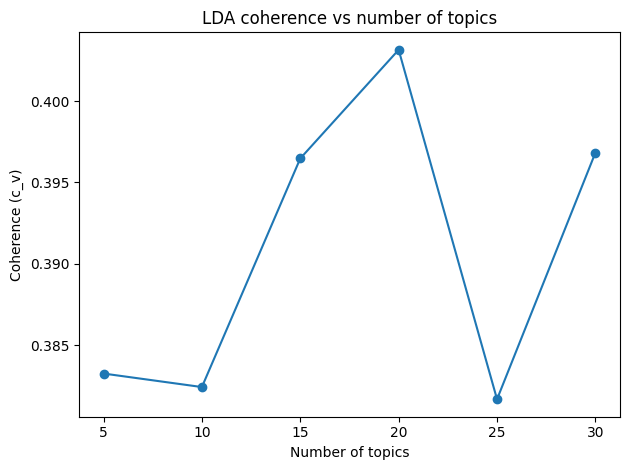

Best number of topics: 20


In [11]:
import matplotlib.pyplot as plt

plt.plot(topic_range, coherence_scores, marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Coherence (c_v)")
plt.title("LDA coherence vs number of topics")
plt.tight_layout()
plt.show()

best_n = topic_range[np.argmax(coherence_scores)]
print(f"Best number of topics: {best_n}")

In [12]:
# train final LDA with the best number of topics
lda_model = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=best_n, random_state=42,
                     passes=15, alpha="auto")

# show top words per topic
for i, topic in lda_model.show_topics(num_topics=best_n, num_words=8, formatted=False):
    words = [w for w, _ in topic]
    print(f"Topic {i}: {words}")

Topic 0: ['take', 'water', 'town', 'time', 'good', 'day', 'pass', 'surround']
Topic 1: ['foot', 'gain', 'elevation', 'difficult', 'loop', 'tackle', 'hour', 'cycle']
Topic 2: ['park', 'natural', 'trail', 'feature', 'moderate', 'waterfall', 'hike', 'difficult']
Topic 3: ['del', 'natural', 'ebro', 'river', 'extremadura', 'old', 'windmill', 'los']
Topic 4: ['trail', 'path', 'start', 'great', 'climb', 'track', 'take', 'accessible']
Topic 5: ['forest', 'moderate', 'loop', 'pine', 'vía', 'verde', 'feature', 'hike']
Topic 6: ['metre', 'moderate', 'cycle', 'duero', 'vineyard', 'scenic', 'river', 'del']
Topic 7: ['historical', 'moderate', 'explore', 'site', 'landscape', 'historic', 'del', 'loop']
Topic 8: ['moderate', 'reservoir', 'view', 'mountain', 'embalse', 'scenic', 'offer', 'loop']
Topic 9: ['view', 'hike', 'panoramic', 'trail', 'moderate', 'circular', 'del', 'offer']
Topic 10: ['climb', 'village', 'peak', 'beautiful', 'offer', 'pass', 'valley', 'basque']
Topic 11: ['hike', 'moderate', 'sa

In [13]:
# convert each document to a topic distribution vector
def doc_to_topic_vector(bow, model, n_topics):
    """Returns a dense vector of topic probabilities for a document."""
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0.0))
    return np.array([topic_dist.get(i, 0.0) for i in range(n_topics)])

lda_matrix = np.array([doc_to_topic_vector(bow, lda_model, best_n)
                        for bow in corpus_bow])
print("LDA matrix shape:", lda_matrix.shape)

np.save("../data/lda_matrix.npy", lda_matrix)
lda_model.save("../data/lda_model")
dictionary.save("../data/lda_dictionary")
print("Saved LDA vectors")

LDA matrix shape: (5642, 20)
Saved LDA vectors


## Step 2d — BERT sentence embeddings (contextual approach)

We use `sentence-transformers` with a lightweight multilingual model.
This model handles English descriptions and would also work with Spanish ones.

In [14]:
from sentence_transformers import SentenceTransformer

# paraphrase-MiniLM
bert_model = SentenceTransformer("paraphrase-MiniLM-L6-v2")

# encode raw descriptions
bert_matrix = bert_model.encode(texts_raw, batch_size=32, show_progress_bar=True)

print("BERT matrix shape:", bert_matrix.shape)
np.save("../data/bert_matrix.npy", bert_matrix)
print("Saved BERT vectors")

/Users/raqueljaen/Desktop/UC3M/4rd Course/2C/MLA/ml-applications-project-repo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 177/177 [00:08<00:00, 21.14it/s]

BERT matrix shape: (5642, 384)
Saved BERT vectors


## PCA visualization of all 4 vectorizations

Trails cluster by sport?

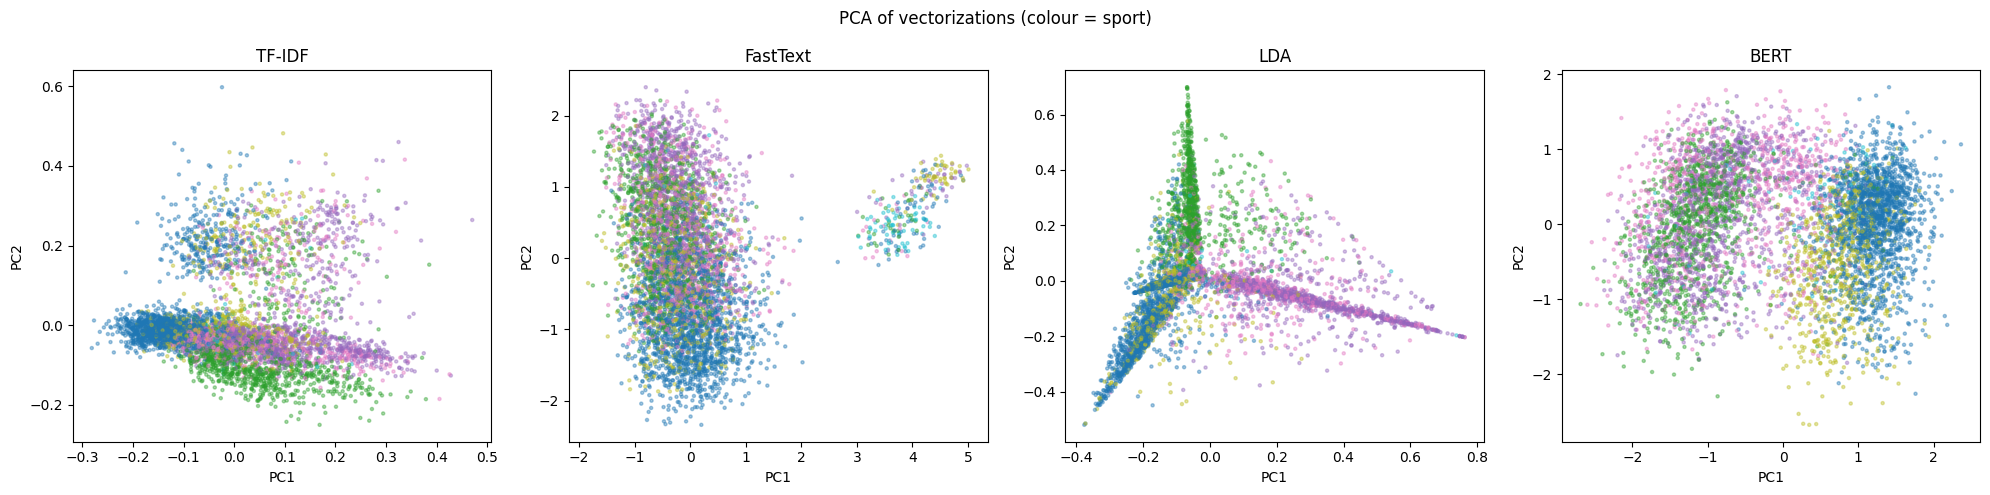

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

matrices = {
    "TF-IDF": tfidf_matrix.toarray(),
    "FastText": fasttext_matrix,
    "LDA": lda_matrix,
    "BERT": bert_matrix,
}

sports = df["sport"].values
sport_labels = {s: i for i, s in enumerate(df["sport"].unique())}
colors = [sport_labels[s] for s in sports]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, matrix) in zip(axes, matrices.items()):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(matrix)
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.4, s=5, cmap="tab10")
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("PCA of vectorizations (colour = sport)")
plt.tight_layout()
plt.savefig("../data/pca_comparison.png", dpi=150)
plt.show()